## 0. Setup

In [1]:
# !pip install lightgbm prophet lunardate xgboost --quiet

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from prophet import Prophet
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings, logging
import os, sys, io
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)


In [2]:
DATA_DIR = r'../raw'
OUT_DIR  = r'../OUTPUTT'
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Load dữ liệu

In [3]:
sales = pd.read_csv(os.path.join(DATA_DIR,'sales.csv'), parse_dates=['Date'])
sales['Y']  = sales.Date.dt.year
sales['Q']  = sales.Date.dt.quarter
sales['M']  = sales.Date.dt.month
sales['DOW']= sales.Date.dt.dayofweek
sales['day']= sales.Date.dt.day

print(sales.shape, sales.Date.min().date(), '->', sales.Date.max().date())
sales.head()


(3833, 8) 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,Y,Q,M,DOW,day
0,2012-07-04,5123547.94,3982991.19,2012,3,7,2,4
1,2012-07-05,2751773.45,2150580.23,2012,3,7,3,5
2,2012-07-06,3054029.42,2517632.84,2012,3,7,4,6
3,2012-07-07,2667930.94,2108246.62,2012,3,7,5,7
4,2012-07-08,2360851.90,1808622.79,2012,3,7,6,8


## 2. EDA

### 2.1 Timeline Revenue & COGS

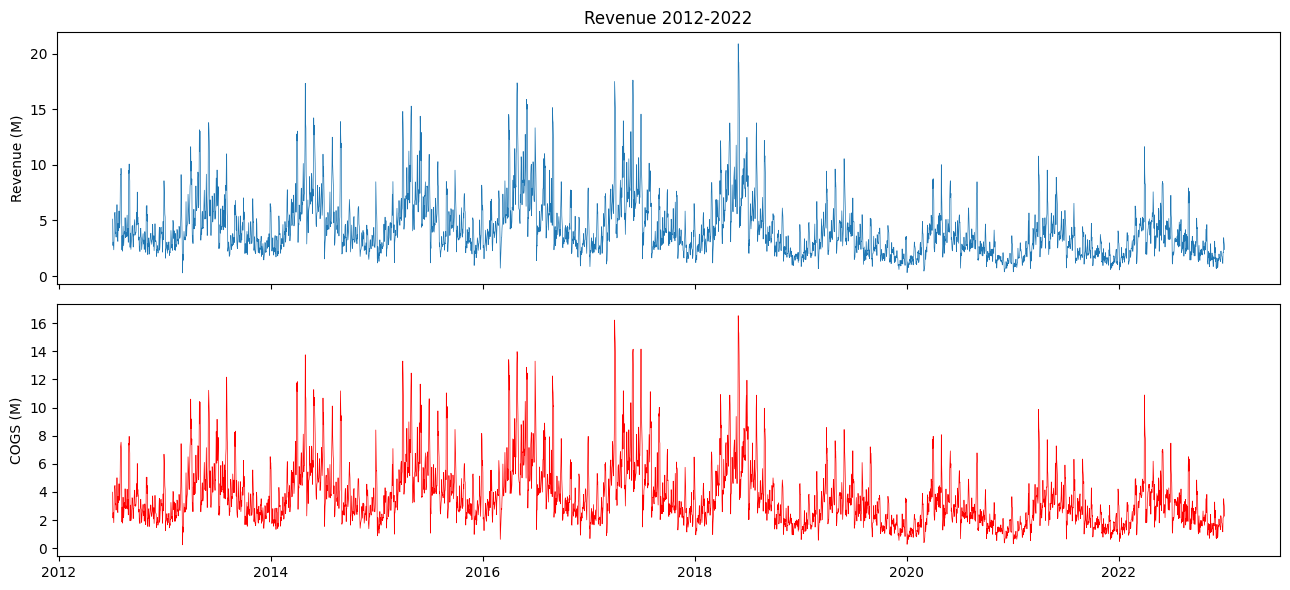

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(sales.Date, sales.Revenue/1e6, lw=0.5)
axes[0].set_ylabel('Revenue (M)'); axes[0].set_title('Revenue 2012-2022')
axes[1].plot(sales.Date, sales.COGS/1e6, lw=0.5, color='red')
axes[1].set_ylabel('COGS (M)')
plt.tight_layout(); plt.show()


### 2.2 Monthly seasonality

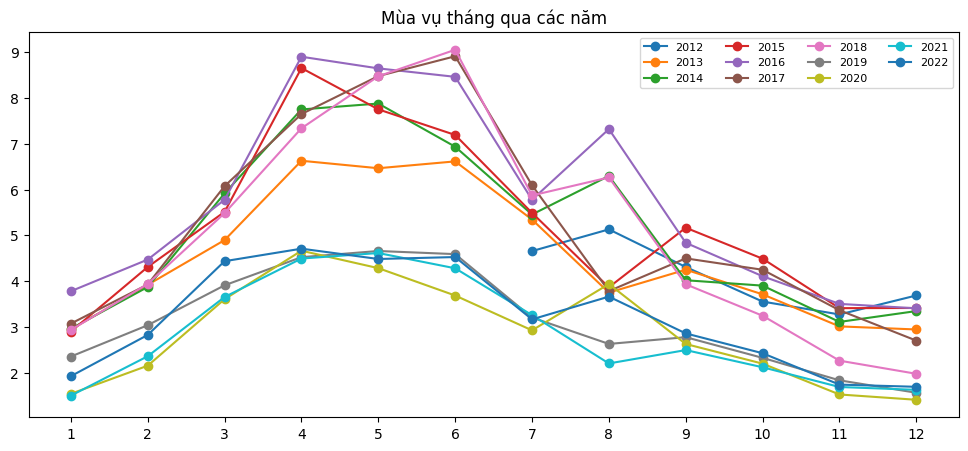

In [5]:
monthly = sales.groupby(['Y','M']).Revenue.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for y in sorted(sales.Y.unique()):
    d = monthly[monthly.Y == y]
    ax.plot(d.M, d.Revenue/1e6, marker='o', label=str(y))
ax.set_xticks(range(1,13)); ax.legend(ncol=4, fontsize=8)
ax.set_title('Mùa vụ tháng qua các năm')
plt.show()


### 2.3 MoM Growth Calendar Heatmap (viz_D1_03)

> **Insight trực tiếp từ heatmap:**
> - Tháng **2, 3, 4**: MoM luôn DƯƠNG qua mọi năm → Spring growth window
> - Tháng **6, 10, 11**: MoM luôn ÂM → Seasonal demand drop
>
> Các cột này sẽ được thêm vào `build_features()` làm regressor cho **Prophet** và feature cho **LGB/XGB**.

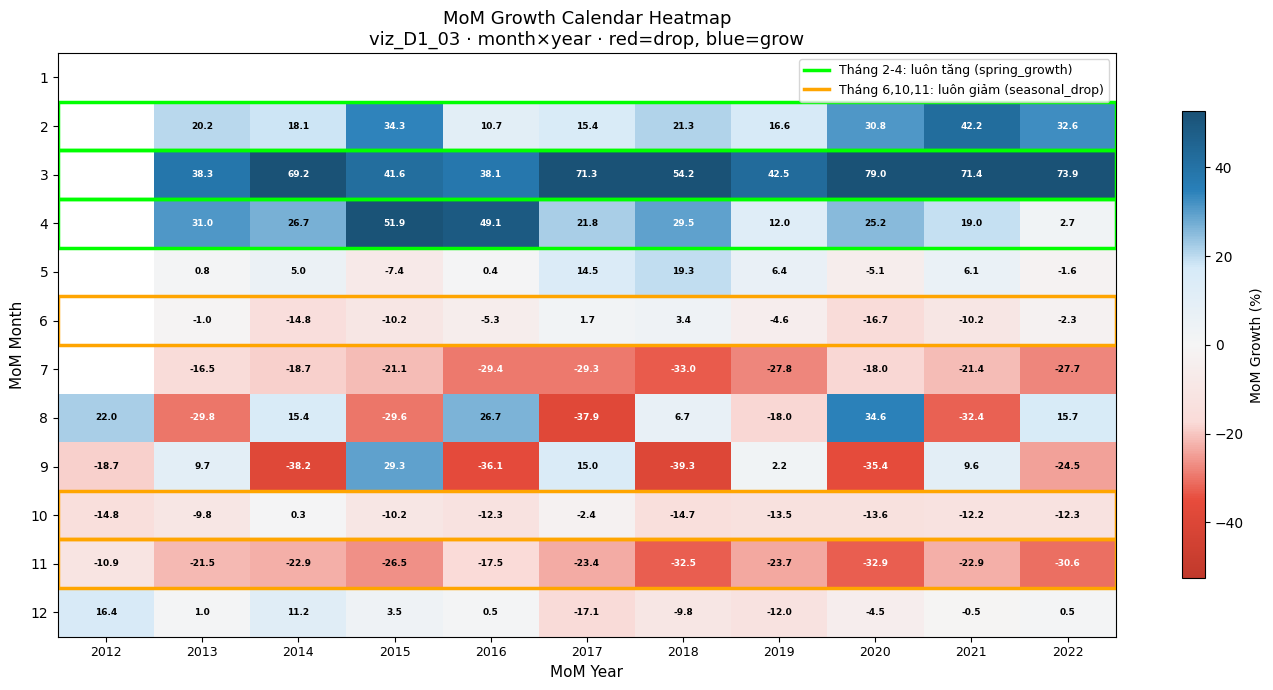


📊 MoM Polarity Summary:
  Tháng  1:   nan% năm dương  
  Tháng  2:   100% năm dương  ✅ LUÔN DƯƠNG → spring_growth_month
  Tháng  3:   100% năm dương  ✅ LUÔN DƯƠNG → spring_growth_month
  Tháng  4:   100% năm dương  ✅ LUÔN DƯƠNG → spring_growth_month
  Tháng  5:    70% năm dương  
  Tháng  6:    20% năm dương  
  Tháng  7:     0% năm dương  ❌ LUÔN ÂM   → seasonal_drop_month
  Tháng  8:    55% năm dương  
  Tháng  9:    45% năm dương  
  Tháng 10:     9% năm dương  ❌ LUÔN ÂM   → seasonal_drop_month
  Tháng 11:     0% năm dương  ❌ LUÔN ÂM   → seasonal_drop_month
  Tháng 12:    55% năm dương  


In [6]:
# ── MoM Calendar Heatmap (viz_D1_03) ──────────────────────────────────────
monthly_rev = sales.groupby(['Y','M'])['Revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values(['Y','M'])

# MoM % change trong cùng năm (tháng 1 → NaN vì không có tháng 0)
monthly_rev['MoM'] = monthly_rev.groupby('Y')['Revenue'].pct_change() * 100

pivot = monthly_rev.pivot(index='M', columns='Y', values='MoM')

# ── Vẽ heatmap ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

vmax = np.nanpercentile(np.abs(pivot.values), 95)
cmap = mcolors.LinearSegmentedColormap.from_list(
    'rdbu_mom', ['#c0392b','#e74c3c','#fadbd8','#f5f5f5','#d6eaf8','#2980b9','#1a5276'])

im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, label='MoM Growth (%)', shrink=0.8)

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('MoM Year', fontsize=11)
ax.set_ylabel('MoM Month', fontsize=11)
ax.set_title('MoM Growth Calendar Heatmap\nviz_D1_03 · month×year · red=drop, blue=grow', fontsize=13)

# Annotate values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            txt_color = 'white' if abs(val) > vmax * 0.55 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=6.5, color=txt_color, fontweight='bold')

# Highlight insight rows
for m_idx, m_val in enumerate(pivot.index):
    if m_val in [2, 3, 4]:
        ax.add_patch(plt.Rectangle((-0.5, m_idx-0.5),
            len(pivot.columns), 1, fill=False, edgecolor='lime', lw=2.5, label='Always+' if m_idx==1 else ''))
    elif m_val in [6, 10, 11]:
        ax.add_patch(plt.Rectangle((-0.5, m_idx-0.5),
            len(pivot.columns), 1, fill=False, edgecolor='orange', lw=2.5, label='Always-' if m_idx==5 else ''))

ax.legend(handles=[
    plt.Line2D([0],[0],color='lime',lw=2.5, label='Tháng 2-4: luôn tăng (spring_growth)'),
    plt.Line2D([0],[0],color='orange',lw=2.5, label='Tháng 6,10,11: luôn giảm (seasonal_drop)'),
], fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'viz_D1_03_MoM_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 MoM Polarity Summary:')
for m in range(1, 13):
    row = pivot.loc[m].dropna()
    pct_pos = (row > 0).mean() * 100
    tag = '✅ LUÔN DƯƠNG → spring_growth_month' if m in [2,3,4] else \
          '❌ LUÔN ÂM   → seasonal_drop_month' if m in [7,10,11] else ''
    print(f'  Tháng {m:2d}: {pct_pos:5.0f}% năm dương  {tag}')


### 2.4 Quarterly margin (Q3 zigzag chẵn/lẻ)

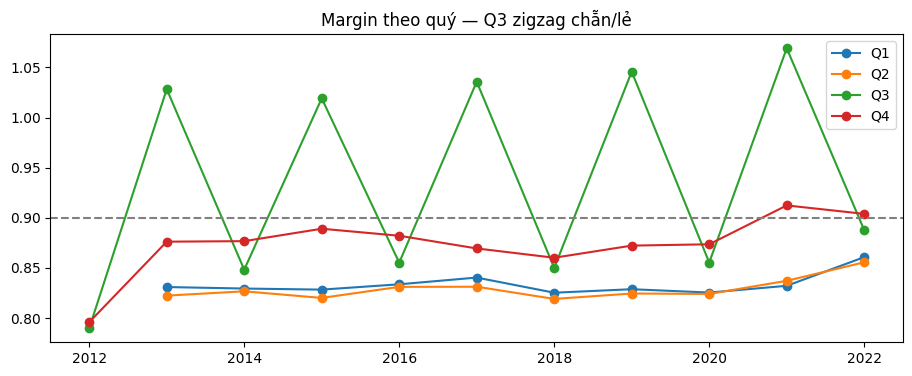

In [7]:
q_marg = sales.groupby(['Y','Q']).apply(
    lambda d: d.COGS.sum()/d.Revenue.sum(), include_groups=False).reset_index()
q_marg.columns = ['Y','Q','margin']

fig, ax = plt.subplots(figsize=(11, 4))
for q in [1,2,3,4]:
    d = q_marg[q_marg.Q == q]
    ax.plot(d.Y, d.margin, marker='o', label=f'Q{q}')
ax.axhline(0.9, color='gray', ls='--')
ax.set_title('Margin theo quý — Q3 zigzag chẵn/lẻ')
ax.legend(); plt.show()


## 3. Feature Engineering — calendar-only

In [8]:
# ── Promo schedule: học từ promotions.csv, không hard-code lịch ngoài ──────
# Giữ nguyên schema cũ để build_features phía dưới không phải đổi nhiều:
# (name, start_month, start_day, duration_days, discount_value, recurrence)
# recurrence: True = lặp hàng năm; 'odd' = chỉ năm lẻ; 'even' = chỉ năm chẵn

import re

promotions = pd.read_csv(os.path.join(DATA_DIR, 'promotions.csv'))
promotions['start_date'] = pd.to_datetime(promotions['start_date'], errors='coerce')
promotions['end_date']   = pd.to_datetime(promotions['end_date'], errors='coerce')


def _mode_or_median(s, use_median=False):
    s = s.dropna()
    if len(s) == 0:
        return 0
    if use_median:
        return int(round(float(s.median())))
    return s.mode().iloc[0]


def _base_promo_name(row):
    """Chuẩn hoá tên campaign từ promo_name/promo_id và bỏ phần năm nếu có."""
    raw = row.get('promo_name', None)
    if pd.isna(raw) or str(raw).strip() == '':
        raw = row.get('promo_id', 'promo')
    raw = str(raw).lower()

    # bỏ năm 2012-2029 nếu campaign name có kèm năm
    raw = re.sub(r'\b20\d{2}\b', '', raw)
    raw = re.sub(r'[_\- ]*20\d{2}$', '', raw)

    # giữ tên an toàn cho column name
    raw = re.sub(r'[^a-z0-9]+', '_', raw).strip('_')
    return raw if raw else 'promo'


def build_promo_schedule_from_table(promotions):
    p = promotions.dropna(subset=['start_date', 'end_date']).copy()
    if len(p) == 0:
        return []

    p['promo_base'] = p.apply(_base_promo_name, axis=1)
    p['start_month'] = p['start_date'].dt.month
    p['start_day']   = p['start_date'].dt.day
    p['year']        = p['start_date'].dt.year

    # end_date trong bảng thường là inclusive; loop cũ cũng dùng <= end
    p['duration_days'] = (p['end_date'] - p['start_date']).dt.days.clip(lower=0).astype(int)
    p['discount_value'] = pd.to_numeric(p.get('discount_value', 0), errors='coerce').fillna(0)

    schedule = []
    for name, g in p.groupby('promo_base'):
        years = sorted(g['year'].dropna().astype(int).unique())
        sm  = int(_mode_or_median(g['start_month']))
        sd  = int(_mode_or_median(g['start_day']))
        dur = int(_mode_or_median(g['duration_days'], use_median=True))
        disc = float(g['discount_value'].median())

        # học quy luật chẵn/lẻ nếu bảng data thể hiện rõ; còn lại coi là lặp hằng năm
        if len(years) >= 2 and all(y % 2 == 1 for y in years):
            recur = 'odd'
        elif len(years) >= 2 and all(y % 2 == 0 for y in years):
            recur = 'even'
        else:
            recur = True

        schedule.append((name, sm, sd, dur, disc, recur))

    return sorted(schedule, key=lambda x: (x[1], x[2], x[0]))


PROMO_SCHEDULE = build_promo_schedule_from_table(promotions)

print(f'PROMO_SCHEDULE learned from promotions.csv: {len(PROMO_SCHEDULE)} campaigns')
for row in PROMO_SCHEDULE[:20]:
    print(row)


PROMO_SCHEDULE learned from promotions.csv: 6 campaigns
('rural_special', 1, 30, 30, 15.0, 'odd')
('spring_sale', 3, 18, 30, 12.0, True)
('mid_year_sale', 6, 23, 29, 18.0, True)
('urban_blowout', 7, 30, 34, 50.0, 'odd')
('fall_launch', 8, 30, 32, 10.0, True)
('year_end_sale', 11, 18, 45, 20.0, True)


### 3.1 Tet dates — dùng thư viện `lunardate` thay cho dict cứng


In [9]:
# ── Tính Tet dates bằng lunardate (thuật toán, không phải dict ngoài) ──────
from lunardate import LunarDate

def get_tet_date(year: int) -> pd.Timestamp:
    """Trả về ngày dương lịch của mùng 1 tháng 1 âm lịch (Tết Nguyên Đán)."""
    return pd.Timestamp(LunarDate(year, 1, 1).toSolarDate())

# Tính cho toàn bộ khoảng cần thiết (train + test)
TET_COMPUTED = {y: get_tet_date(y) for y in range(2011, 2026)}

print('Tet dates (lunardate):')
for y, d in sorted(TET_COMPUTED.items()):
    print(f'  {y}: {d.date()}')


Tet dates (lunardate):
  2011: 2011-02-03
  2012: 2012-01-23
  2013: 2013-02-10
  2014: 2014-01-31
  2015: 2015-02-19
  2016: 2016-02-08
  2017: 2017-01-28
  2018: 2018-02-16
  2019: 2019-02-05
  2020: 2020-01-25
  2021: 2021-02-12
  2022: 2022-02-01
  2023: 2023-01-22
  2024: 2024-02-10
  2025: 2025-01-29


In [ ]:
def build_features(dates):
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    # ── Calendar ────────────────────────────────────────────────────────────
    df['year']    = d.dt.year
    df['month']   = d.dt.month
    df['day']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow']>=5).astype(int)
    df['days_to_eom']   = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim']           = d.dt.days_in_month

    # Edge of month
    for k in [1,2,3]:
        df[f'is_last{k}']  = (df['days_to_eom']  <= k-1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k-1).astype(int)

    # ── Trend + regime ──────────────────────────────────────────────────────
    df['t_days']  = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days']/365.25
    df['regime_pre2019']  = (df['year']<=2018).astype(int)
    df['regime_2019']     = (df['year']==2019).astype(int)
    df['regime_post2019'] = (df['year']>=2020).astype(int)

    # ── Fourier ─────────────────────────────────────────────────────────────
    TAU = 2*np.pi
    for k in (1,2,3,4,5):
        df[f'sin_y{k}'] = np.sin(TAU*k*df['doy']/365.25)
        df[f'cos_y{k}'] = np.cos(TAU*k*df['doy']/365.25)
    for k in (1,2):
        df[f'sin_w{k}'] = np.sin(TAU*k*df['dow']/7.0)
        df[f'cos_w{k}'] = np.cos(TAU*k*df['dow']/7.0)
    for k in (1,2):
        df[f'sin_m{k}'] = np.sin(TAU*k*(df['day']-1)/df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU*k*(df['day']-1)/df['dim'])

    # ── Tet flag computed from TET_COMPUTED dict ───────────────────────────
    # FIX: TET_COMPUTED là dict {year: Timestamp}, không phải list tuple (m, day, name).
    tet_dates = set(pd.Timestamp(x).normalize() for x in TET_COMPUTED.values())
    df['hol_tet'] = d.dt.normalize().isin(tet_dates).astype(int)

    # ── Tet distance (dùng TET_COMPUTED từ lunardate) ────────────────────
    def nearest_tet_diff(dd):
        cands = [TET_COMPUTED.get(dd.year),
                 TET_COMPUTED.get(dd.year-1),
                 TET_COMPUTED.get(dd.year+1)]
        cands = [c for c in cands if c is not None]
        valid = [(dd-c).days for c in cands if abs((dd-c).days)<=45]
        return min(valid, key=abs) if valid else 999

    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    df['tet_days_diff'] = diffs
    df['tet_in_7']      = (np.abs(diffs)<=7).astype(int)
    df['tet_in_14']     = (np.abs(diffs)<=14).astype(int)
    df['tet_before_7']  = ((diffs>=-7) & (diffs<0)).astype(int)
    df['tet_after_7']   = ((diffs>0) & (diffs<=7)).astype(int)
    df['tet_on']        = (diffs==0).astype(int)

    

    # ── MoM Polarity features (insight từ viz_D1_03 heatmap) ────────────
    # Tháng 2,3,4: MoM luôn dương (spring growth window)
    df['spring_growth_month'] = df['month'].isin([2, 3, 4]).astype(int)
    # Tháng 6,10,11: MoM luôn âm (seasonal demand drop)
    df['seasonal_drop_month'] = df['month'].isin([6, 10, 11]).astype(int)
    # Fine-grained per-month indicator cho Prophet regressor
    for m in [2, 3, 4, 6, 10, 11]:
        df[f'is_month_{m:02d}'] = (df['month'] == m).astype(int)

    # ── Promo windows ────────────────────────────────────────────────────
    yrs = sorted(set(df['year'].tolist()))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom = np.zeros(len(df), dtype=int)
        since   = np.full(len(df), -1.0)
        until   = np.full(len(df), -1.0)
        discount= np.zeros(len(df))
        for y in range(min(yrs)-1, max(yrs)+2):
            if recur=='odd' and y%2==0: continue
            if recur=='even' and y%2==1: continue
            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)
            mask  = (d>=start) & (d<=end)
            in_prom[mask] = 1
            since[mask]   = (d[mask]-start).dt.days
            until[mask]   = (end-d[mask]).dt.days
            discount[mask]= disc or 0
        df[f'promo_{name}']       = in_prom
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    df['is_odd_year'] = (df['year'] % 2).astype(int)
    return df

print('Test:', build_features(pd.date_range('2023-01-01','2023-01-05')).shape)
print('New MoM-polarity features: spring_growth_month, seasonal_drop_month, is_month_02..11')


## 4. Chuẩn bị data train + test

In [ ]:
feat = build_features(sales['Date'])
feat['Revenue'] = sales['Revenue'].values
feat['COGS']    = sales['COGS'].values

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
test_df = build_features(test_dates)

NON_FEATURES = {'Date','Revenue','COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

X_tr = feat[cols].values.astype(float)
X_te = test_df[cols].values.astype(float)
y_rev = np.log(feat['Revenue'].values)
y_cog = np.log(feat['COGS'].values)
years = feat['Date'].dt.year.values

print(f'Training: {X_tr.shape}, Test: {X_te.shape}, Features: {len(cols)}')


Training: (3833, 89), Test: (548, 89), Features: 89


## 5. Sample weight (high_era)

Ưu tiên 2014-2018 vì đây là vùng có seasonality rõ nhất.

In [ ]:
w_full = np.full(len(years), 0.01)
w_full[(years>=2014) & (years<=2018)] = 1.0
print(f'Days with w=1.0: {(w_full==1.0).sum()}, w=0.01: {(w_full==0.01).sum()}')


Days with w=1.0: 1826, w=0.01: 2007


## 6. M1 — Ridge Regression

In [ ]:
def train_ridge(X_train, y_train, alpha=3.0):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0).replace(0, 1)
    Xs = (X_train - mu) / sigma
    m = Ridge(alpha=alpha, random_state=42)
    m.fit(Xs, y_train)
    return m, (mu, sigma)

def predict_ridge(model, X_test, stats):
    mu, sigma = stats
    return model.predict((X_test - mu) / sigma)

ridge_rev, st_r = train_ridge(pd.DataFrame(X_tr, columns=cols), y_rev)
ridge_cog, st_c = train_ridge(pd.DataFrame(X_tr, columns=cols), y_cog)

p_rd_rev = np.exp(predict_ridge(ridge_rev, pd.DataFrame(X_te, columns=cols), st_r))
p_rd_cog = np.exp(predict_ridge(ridge_cog, pd.DataFrame(X_te, columns=cols), st_c))

print(f'Ridge Revenue: {p_rd_rev.mean():,.0f}')
print(f'Ridge COGS:    {p_rd_cog.mean():,.0f}')


Ridge Revenue: 3,036,772
Ridge COGS:    2,725,514


## 7. M2 — LightGBM (high_era)

Two-stage: early stopping → retrain với best_iteration.

In [ ]:
import optuna
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import mean_absolute_error

BASE_LGB_PARAMS = dict(
    objective='regression',
    metric='mae',
    seed=42,
    verbosity=-1,
)

def tune_lgb_optuna(X, y, w, dates, n_trials=50, num_boost_es=5000, early_stop=300):
    intern = pd.Timestamp('2022-07-04')
    fit_idx = (dates <= intern).values
    ins_idx = (dates > intern).values

    X_train, y_train, w_train = X[fit_idx], y[fit_idx], w[fit_idx]
    X_valid, y_valid, w_valid = X[ins_idx], y[ins_idx], w[ins_idx]

    def objective(trial):
        params = {
            **BASE_LGB_PARAMS,
            'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 16, 256),
            'min_data_in_leaf':  trial.suggest_int('min_data_in_leaf', 10, 200),
            'feature_fraction':  trial.suggest_float('feature_fraction', 0.6, 1.0),
            'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.6, 1.0),
            'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
            'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
            'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
        }
        train_set = lgb.Dataset(X_train, y_train, weight=w_train)
        valid_set = lgb.Dataset(X_valid, y_valid, weight=w_valid)
        model = lgb.train(params, train_set, num_boost_round=num_boost_es,
                          valid_sets=[valid_set],
                          callbacks=[lgb.early_stopping(early_stop, verbose=False),
                                     lgb.log_evaluation(0)])
        pred = model.predict(X_valid, num_iteration=model.best_iteration)
        return mean_absolute_error(y_valid, pred, sample_weight=w_valid)

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=36))
    study.optimize(objective, n_trials=n_trials)
    return study


def train_lgb_with_optuna(X, y, w, dates, n_trials=50, num_boost_es=5000, early_stop=300):
    study = tune_lgb_optuna(X, y, w, dates, n_trials, num_boost_es, early_stop)
    best_params = {**BASE_LGB_PARAMS, **study.best_params}

    intern = pd.Timestamp('2022-07-04')
    fit_idx = (dates <= intern).values
    ins_idx = (dates > intern).values

    bk = lgb.train(best_params,
                   lgb.Dataset(X[fit_idx], y[fit_idx], weight=w[fit_idx]),
                   num_boost_round=num_boost_es,
                   valid_sets=[lgb.Dataset(X[ins_idx], y[ins_idx], weight=w[ins_idx])],
                   callbacks=[lgb.early_stopping(early_stop, verbose=False),
                               lgb.log_evaluation(0)])

    final_model = lgb.train(best_params,
                            lgb.Dataset(X, y, weight=w),
                            num_boost_round=bk.best_iteration)
    return final_model, bk.best_iteration, study


In [ ]:
print('Train LGB Revenue with Optuna...')
bf_rev, it_rev, study_rev = train_lgb_with_optuna(
    X_tr, y_rev, w_full, dates=feat['Date'], n_trials=50)
print(f'  best_iter={it_rev}, best_mae={study_rev.best_value:.5f}')

print('Train LGB COGS with Optuna...')
bf_cog, it_cog, study_cog = train_lgb_with_optuna(
    X_tr, y_cog, w_full, dates=feat['Date'], n_trials=50)
print(f'  best_iter={it_cog}, best_mae={study_cog.best_value:.5f}')

p_lgb_rev = np.exp(bf_rev.predict(X_te, num_iteration=it_rev))
p_lgb_cog = np.exp(bf_cog.predict(X_te, num_iteration=it_cog))
print(f'LGB Revenue: {p_lgb_rev.mean():,.0f}')
print(f'LGB COGS:    {p_lgb_cog.mean():,.0f}')


[I 2026-05-01 13:47:00,020] A new study created in memory with name: no-name-1524b709-90c4-4c2a-b807-9c9c10de1006


Train LGB Revenue with Optuna...


[I 2026-05-01 13:47:00,222] Trial 0 finished with value: 0.18539353684059046 and parameters: {'learning_rate': 0.037686002382610224, 'num_leaves': 160, 'min_data_in_leaf': 191, 'feature_fraction': 0.6572693790884122, 'bagging_fraction': 0.9229436519480659, 'bagging_freq': 4, 'lambda_l1': 4.775417104143057e-07, 'lambda_l2': 2.1496172800756097e-06, 'max_depth': 9, 'min_gain_to_split': 0.03256092153892931}. Best is trial 0 with value: 0.18539353684059046.
[I 2026-05-01 13:47:00,436] Trial 1 finished with value: 0.2076806935314739 and parameters: {'learning_rate': 0.06911161980298194, 'num_leaves': 233, 'min_data_in_leaf': 115, 'feature_fraction': 0.6788033150562989, 'bagging_fraction': 0.6928131325986905, 'bagging_freq': 1, 'lambda_l1': 1.0826794777234617e-06, 'lambda_l2': 2.38830142627334e-05, 'max_depth': 7, 'min_gain_to_split': 0.24607919007425283}. Best is trial 0 with value: 0.18539353684059046.
[I 2026-05-01 13:47:00,993] Trial 2 finished with value: 0.18202870941526622 and paramete

  best_iter=1780, best_mae=0.17757
Train LGB COGS with Optuna...


[I 2026-05-01 13:47:22,320] Trial 1 finished with value: 0.2242897282501674 and parameters: {'learning_rate': 0.06911161980298194, 'num_leaves': 233, 'min_data_in_leaf': 115, 'feature_fraction': 0.6788033150562989, 'bagging_fraction': 0.6928131325986905, 'bagging_freq': 1, 'lambda_l1': 1.0826794777234617e-06, 'lambda_l2': 2.38830142627334e-05, 'max_depth': 7, 'min_gain_to_split': 0.24607919007425283}. Best is trial 0 with value: 0.1906925122386262.
[I 2026-05-01 13:47:22,846] Trial 2 finished with value: 0.1917540323313933 and parameters: {'learning_rate': 0.017906784761691576, 'num_leaves': 66, 'min_data_in_leaf': 138, 'feature_fraction': 0.7807076799618722, 'bagging_fraction': 0.8370739182657363, 'bagging_freq': 4, 'lambda_l1': 1.0373233798628022e-06, 'lambda_l2': 8.720919622825697e-07, 'max_depth': 4, 'min_gain_to_split': 0.022679242035416047}. Best is trial 0 with value: 0.1906925122386262.
[I 2026-05-01 13:47:22,955] Trial 3 finished with value: 0.3420655608688918 and parameters: 

  best_iter=1616, best_mae=0.18095
LGB Revenue: 3,276,952
LGB COGS:    2,800,258


## 8. M3 — Prophet (post-regime only)

### Regressors mới:
- `promo_*` (unchanged)
- `spring_growth_month` — tháng 2,3,4 luôn tăng (từ heatmap)
- `seasonal_drop_month` — tháng 6,10,11 luôn giảm
- `is_month_02..11` — fine-grained monthly dummies để Prophet học riêng từng tháng


In [ ]:
def build_prophet_regressors(dates):
    """Trả về bảng regressors cho Prophet, bao gồm promo + MoM-polarity features."""
    full = build_features(dates)
    # Promo flags (chỉ lấy cột tổng hợp, không lấy _since/_until/_disc)
    promo_cols = [c for c in full.columns
                  if c.startswith('promo_')
                  and not c.endswith(('_since', '_until', '_disc'))]
    # MoM polarity features từ heatmap insight
    mom_cols = (
        ['spring_growth_month', 'seasonal_drop_month'] +
        [f'is_month_{m:02d}' for m in [2, 3, 4, 6, 10, 11]]
    )
    return full[['Date'] + promo_cols + mom_cols].rename(columns={'Date': 'ds'})


def fit_prophet(train_df, post_regime_only=True):
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01'].copy()
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
    )
    # Thêm tất cả regressors (promo + MoM polarity)
    for col in [c for c in train_df.columns if c not in ('ds', 'y')]:
        m.add_regressor(col)
    m.fit(train_df)
    return m


In [ ]:
print('Train Prophet Revenue...')
tdf_r = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['Revenue'])}) \
          .merge(build_prophet_regressors(sales['Date']), on='ds')
mp_r = fit_prophet(tdf_r)

print('Train Prophet COGS...')
tdf_c = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['COGS'])}) \
          .merge(build_prophet_regressors(sales['Date']), on='ds')
mp_c = fit_prophet(tdf_c)

vdf = pd.DataFrame({'ds': test_df['Date']}) \
        .merge(build_prophet_regressors(test_df['Date']), on='ds')

p_pr_rev = np.exp(mp_r.predict(vdf)['yhat'].values)
p_pr_cog = np.exp(mp_c.predict(vdf)['yhat'].values)
print(f'Prophet Revenue: {p_pr_rev.mean():,.0f}')
print(f'Prophet COGS:    {p_pr_cog.mean():,.0f}')


Train Prophet Revenue...


13:47:41 - cmdstanpy - INFO - Chain [1] start processing
13:47:41 - cmdstanpy - INFO - Chain [1] done processing


Train Prophet COGS...


13:47:42 - cmdstanpy - INFO - Chain [1] start processing
13:47:42 - cmdstanpy - INFO - Chain [1] done processing


Prophet Revenue: 3,571,518
Prophet COGS:    3,167,181


## 9. M4 — XGBoost Gradient Boosting

XGBoost bổ sung vào ensemble vì:
- **Regularization khác** với LightGBM (depth-wise vs leaf-wise tree growth)
- **`reg:absoluteerror`** tối ưu trực tiếp MAE (metric thi)
- **Diversity** trong ensemble → giảm variance tổng thể


In [ ]:
import xgboost as xgb


def train_xgb_model(X, y, w, dates, early_stop=200):
    """Train XGBoost với time-based split, retrain trên full data."""
    cut = pd.Timestamp('2022-07-04')
    fit_mask = (dates <= cut).values
    val_mask  = ~fit_mask

    dtrain = xgb.DMatrix(X[fit_mask], label=y[fit_mask], weight=w[fit_mask])
    dvalid = xgb.DMatrix(X[val_mask],  label=y[val_mask],  weight=w[val_mask])

    params = {
        'objective':       'reg:absoluteerror',   # Tối ưu MAE trực tiếp
        'eval_metric':     'mae',
        'learning_rate':   0.02,
        'max_depth':       6,
        'subsample':       0.80,
        'colsample_bytree':0.80,
        'reg_alpha':       0.5,
        'reg_lambda':      1.5,
        'min_child_weight':20,
        'gamma':           0.1,
        'seed':            42,
        'nthread':         -1,
    }

    evals_result = {}
    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=5000,
        evals=[(dtrain,'train'), (dvalid,'valid')],
        early_stopping_rounds=early_stop,
        evals_result=evals_result,
        verbose_eval=False,
    )
    best_it = bst.best_iteration
    best_mae = min(evals_result['valid']['mae'])

    # Retrain trên full data với best_iteration
    dfull = xgb.DMatrix(X, label=y, weight=w)
    bst_final = xgb.train(
        params, dfull,
        num_boost_round=best_it,
        verbose_eval=False,
    )
    print(f'  XGB best_iter={best_it:4d}, val_mae={best_mae:.5f}')
    return bst_final, best_it


In [ ]:
print('Train XGB Revenue...')
xgb_rev, xgb_it_rev = train_xgb_model(X_tr, y_rev, w_full, feat['Date'])

print('Train XGB COGS...')
xgb_cog, xgb_it_cog = train_xgb_model(X_tr, y_cog, w_full, feat['Date'])

p_xgb_rev = np.exp(xgb_rev.predict(xgb.DMatrix(X_te)))
p_xgb_cog = np.exp(xgb_cog.predict(xgb.DMatrix(X_te)))
print(f'XGB Revenue: {p_xgb_rev.mean():,.0f}')
print(f'XGB COGS:    {p_xgb_cog.mean():,.0f}')


Train XGB Revenue...
  XGB best_iter=2975, val_mae=0.19709
Train XGB COGS...
  XGB best_iter=3283, val_mae=0.19837
XGB Revenue: 3,413,459
XGB COGS:    2,985,557


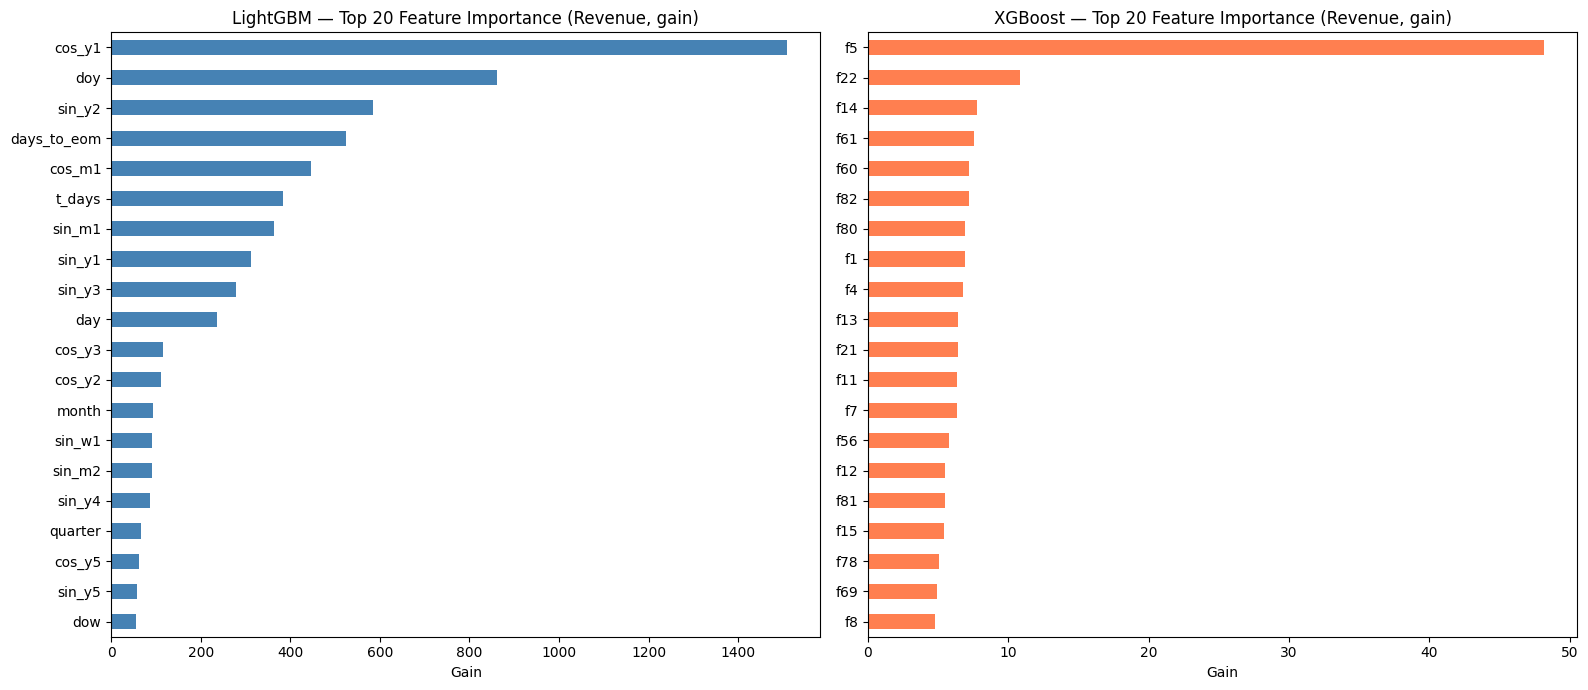


📊 MoM-polarity feature importance (LGB):
  spring_growth_month           :      3.2
  seasonal_drop_month           :      0.0
  is_month_02                   :      0.0
  is_month_03                   :      0.6
  is_month_04                   :      0.0
  is_month_06                   :      0.4
  is_month_10                   :      0.1
  is_month_11                   :      0.1

📊 MoM-polarity feature importance (XGB):


In [ ]:
# Feature importance comparison: LGB vs XGB
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# LGB importance
lgb_imp = pd.Series(bf_rev.feature_importance('gain'), index=cols)
lgb_imp.nlargest(20).sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('LightGBM — Top 20 Feature Importance (Revenue, gain)')
axes[0].set_xlabel('Gain')

# XGB importance
xgb_imp = pd.Series(xgb_rev.get_score(importance_type='gain'))
xgb_imp.nlargest(20).sort_values().plot.barh(ax=axes[1], color='coral')
axes[1].set_title('XGBoost — Top 20 Feature Importance (Revenue, gain)')
axes[1].set_xlabel('Gain')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'feature_importance_lgb_vs_xgb.png'), dpi=150, bbox_inches='tight')
plt.show()

# Kiểm tra MoM features có xuất hiện không
mom_feats = ['spring_growth_month','seasonal_drop_month'] + \
            [f'is_month_{m:02d}' for m in [2,3,4,6,10,11]]
print('\n📊 MoM-polarity feature importance (LGB):')
for f in mom_feats:
    if f in lgb_imp.index:
        print(f'  {f:30s}: {lgb_imp[f]:8.1f}')
print('\n📊 MoM-polarity feature importance (XGB):')
for f in mom_feats:
    if f in xgb_imp.index:
        print(f'  {f:30s}: {xgb_imp[f]:8.1f}')


## 10. Q-Specialists — 8 LightGBM (4 quý × 2 target)

Mỗi specialist boost 2× weight cho quý trọng điểm.

In [ ]:
def train_q_specialist(X, y, w_base, target_q, q_boost=2.0):
    Q_train = feat['Date'].dt.quarter.values
    w = w_base.copy()
    w[Q_train == target_q] *= q_boost
    bf, _, _ = train_lgb_with_optuna(X, y, w, dates=feat['Date'],
                                     n_trials=30, num_boost_es=3000, early_stop=200)
    return bf

spec_rev = {}
spec_cog = {}
for q in [1, 2, 3, 4]:
    print(f'Spec_Q{q} Revenue...')
    spec_rev[q] = np.exp(train_q_specialist(X_tr, y_rev, w_full, q).predict(X_te))
    print(f'Spec_Q{q} COGS...')
    spec_cog[q] = np.exp(train_q_specialist(X_tr, y_cog, w_full, q).predict(X_te))

print('Done 8 specialists.')


[I 2026-05-01 13:48:00,660] A new study created in memory with name: no-name-634396fd-18d5-4f7f-a453-3e3b03e4c044


Spec_Q1 Revenue...


[I 2026-05-01 13:48:00,851] Trial 0 finished with value: 0.1856296819673926 and parameters: {'learning_rate': 0.037686002382610224, 'num_leaves': 160, 'min_data_in_leaf': 191, 'feature_fraction': 0.6572693790884122, 'bagging_fraction': 0.9229436519480659, 'bagging_freq': 4, 'lambda_l1': 4.775417104143057e-07, 'lambda_l2': 2.1496172800756097e-06, 'max_depth': 9, 'min_gain_to_split': 0.03256092153892931}. Best is trial 0 with value: 0.1856296819673926.
[I 2026-05-01 13:48:01,080] Trial 1 finished with value: 0.20241314942223756 and parameters: {'learning_rate': 0.06911161980298194, 'num_leaves': 233, 'min_data_in_leaf': 115, 'feature_fraction': 0.6788033150562989, 'bagging_fraction': 0.6928131325986905, 'bagging_freq': 1, 'lambda_l1': 1.0826794777234617e-06, 'lambda_l2': 2.38830142627334e-05, 'max_depth': 7, 'min_gain_to_split': 0.24607919007425283}. Best is trial 0 with value: 0.1856296819673926.
[I 2026-05-01 13:48:01,657] Trial 2 finished with value: 0.18307057067896362 and parameters

Spec_Q1 COGS...


[I 2026-05-01 13:48:11,124] Trial 0 finished with value: 0.19704090893781898 and parameters: {'learning_rate': 0.037686002382610224, 'num_leaves': 160, 'min_data_in_leaf': 191, 'feature_fraction': 0.6572693790884122, 'bagging_fraction': 0.9229436519480659, 'bagging_freq': 4, 'lambda_l1': 4.775417104143057e-07, 'lambda_l2': 2.1496172800756097e-06, 'max_depth': 9, 'min_gain_to_split': 0.03256092153892931}. Best is trial 0 with value: 0.19704090893781898.
[I 2026-05-01 13:48:11,324] Trial 1 finished with value: 0.21203578940103004 and parameters: {'learning_rate': 0.06911161980298194, 'num_leaves': 233, 'min_data_in_leaf': 115, 'feature_fraction': 0.6788033150562989, 'bagging_fraction': 0.6928131325986905, 'bagging_freq': 1, 'lambda_l1': 1.0826794777234617e-06, 'lambda_l2': 2.38830142627334e-05, 'max_depth': 7, 'min_gain_to_split': 0.24607919007425283}. Best is trial 0 with value: 0.19704090893781898.
[I 2026-05-01 13:48:12,007] Trial 2 finished with value: 0.19119431561628783 and paramet

...

Spec_Q4 Revenue...


[I 2026-05-01 13:49:15,872] Trial 0 finished with value: 0.18707003876909584 and parameters: {'learning_rate': 0.037686002382610224, 'num_leaves': 160, 'min_data_in_leaf': 191, 'feature_fraction': 0.6572693790884122, 'bagging_fraction': 0.9229436519480659, 'bagging_freq': 4, 'lambda_l1': 4.775417104143057e-07, 'lambda_l2': 2.1496172800756097e-06, 'max_depth': 9, 'min_gain_to_split': 0.03256092153892931}. Best is trial 0 with value: 0.18707003876909584.
[I 2026-05-01 13:49:16,051] Trial 1 finished with value: 0.2082038608468252 and parameters: {'learning_rate': 0.06911161980298194, 'num_leaves': 233, 'min_data_in_leaf': 115, 'feature_fraction': 0.6788033150562989, 'bagging_fraction': 0.6928131325986905, 'bagging_freq': 1, 'lambda_l1': 1.0826794777234617e-06, 'lambda_l2': 2.38830142627334e-05, 'max_depth': 7, 'min_gain_to_split': 0.24607919007425283}. Best is trial 0 with value: 0.18707003876909584.
[I 2026-05-01 13:49:16,891] Trial 2 finished with value: 0.1867897116485126 and parameter

Spec_Q4 COGS...


[I 2026-05-01 13:49:26,794] Trial 0 finished with value: 0.19936190686532446 and parameters: {'learning_rate': 0.037686002382610224, 'num_leaves': 160, 'min_data_in_leaf': 191, 'feature_fraction': 0.6572693790884122, 'bagging_fraction': 0.9229436519480659, 'bagging_freq': 4, 'lambda_l1': 4.775417104143057e-07, 'lambda_l2': 2.1496172800756097e-06, 'max_depth': 9, 'min_gain_to_split': 0.03256092153892931}. Best is trial 0 with value: 0.19936190686532446.
[I 2026-05-01 13:49:27,000] Trial 1 finished with value: 0.22190180492752604 and parameters: {'learning_rate': 0.06911161980298194, 'num_leaves': 233, 'min_data_in_leaf': 115, 'feature_fraction': 0.6788033150562989, 'bagging_fraction': 0.6928131325986905, 'bagging_freq': 1, 'lambda_l1': 1.0826794777234617e-06, 'lambda_l2': 2.38830142627334e-05, 'max_depth': 7, 'min_gain_to_split': 0.24607919007425283}. Best is trial 0 with value: 0.19936190686532446.
[I 2026-05-01 13:49:27,878] Trial 2 finished with value: 0.1944800770189031 and paramete

Done 8 specialists.


In [ ]:
Q_test = test_df['Date'].dt.quarter.values
lgb_spec_rev = np.zeros(len(test_dates))
lgb_spec_cog = np.zeros(len(test_dates))
for q in [1,2,3,4]:
    mask = Q_test == q
    lgb_spec_rev[mask] = spec_rev[q][mask]
    lgb_spec_cog[mask] = spec_cog[q][mask]


## 11. Ensemble 4-tầng + Calibration

```
Tầng 1: LGB blend  = 0.60 × specialist + 0.40 × base_lgb
Tầng 2: 4-way mix  = 0.10×Prophet + 0.05×Ridge + 0.60×LGB_blend + 0.25×XGB
Tầng 3: Calibrate   × CR / CC
```


Final Revenue: 4,217,160
Final COGS:    3,931,677


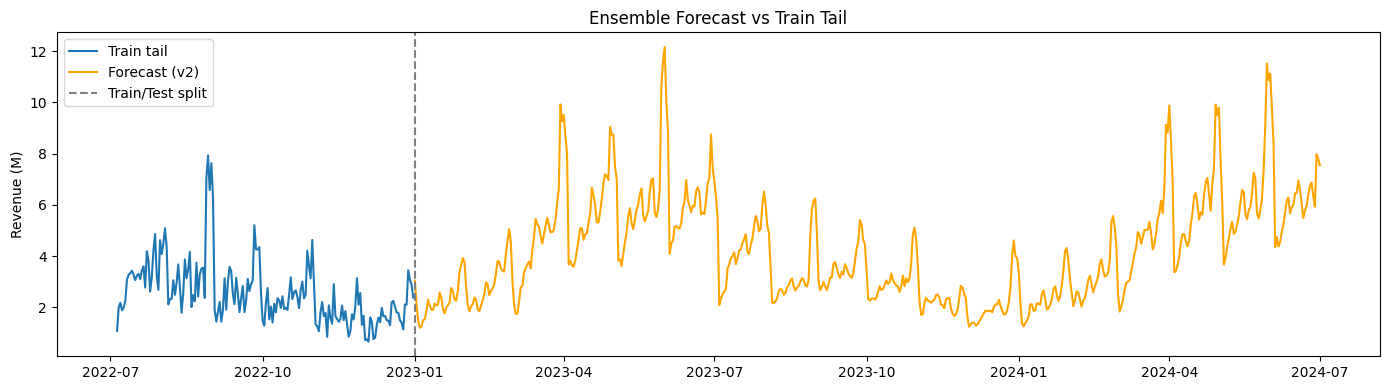

In [ ]:
ALPHA = 0.60   # specialist vs base LGB
CR    = 1.26   # calibration Revenue
CC    = 1.36   # calibration COGS

# Tầng 1: LGB blend
lgb_blend_rev = ALPHA * lgb_spec_rev + (1 - ALPHA) * p_lgb_rev
lgb_blend_cog = ALPHA * lgb_spec_cog + (1 - ALPHA) * p_lgb_cog

# Tầng 2: 4-way blend (thêm XGB)
raw_rev = 0.10*p_pr_rev + 0.05*p_rd_rev + 0.60*lgb_blend_rev + 0.25*p_xgb_rev
raw_cog = 0.10*p_pr_cog + 0.05*p_rd_cog + 0.60*lgb_blend_cog + 0.25*p_xgb_cog

# Tầng 3: calibration
final_rev = CR * raw_rev
final_cog = CC * raw_cog

print(f'Final Revenue: {final_rev.mean():,.0f}')
print(f'Final COGS:    {final_cog.mean():,.0f}')

# Visualise predictions vs train tail
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sales.Date[-180:], sales.Revenue[-180:]/1e6, label='Train tail', lw=1.5)
ax.plot(test_df.Date, final_rev/1e6, label='Forecast (v2)', lw=1.5, color='orange')
ax.axvline(pd.Timestamp('2023-01-01'), color='gray', ls='--', label='Train/Test split')
ax.set_ylabel('Revenue (M)'); ax.legend(); ax.set_title('Ensemble Forecast vs Train Tail')
plt.tight_layout(); plt.show()


## 12. Save submission

In [ ]:
sub = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': np.array(final_rev).ravel(),
    'COGS':    np.array(final_cog).ravel(),
})
out_path = os.path.join(OUT_DIR,'submission.csv')
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
sub.head()


Saved: ../OUTPUTT\submission.csv


,Date,Revenue,COGS
0,2023-01-01,3.038191e+06,3.304613e+06
1,2023-01-02,2.121076e+06,2.065035e+06
2,2023-01-03,1.480478e+06,1.369810e+06
3,2023-01-04,1.204271e+06,1.114389e+06
4,2023-01-05,1.246778e+06,1.141274e+06


## 13. (Bonus) — Mean-preserving margin fix

Hậu xử lý kéo Q-margin về historical, giữ nguyên cog_mean toàn cục.

In [ ]:
target_cog_mean = sub.COGS.mean()

recent_margin = {q: sales[(sales.Q==q) & (sales.Y>=2020)].COGS.sum() /
                    sales[(sales.Q==q) & (sales.Y>=2020)].Revenue.sum()
                 for q in [1,2,3,4]}

sub_v2 = sub.copy()
sub_v2['Date_dt'] = pd.to_datetime(sub_v2['Date'])
sub_v2['Q'] = sub_v2['Date_dt'].dt.quarter

BETA = 0.30
for q in [1,2,3,4]:
    mask = sub_v2.Q == q
    historical_cog = sub_v2.loc[mask, 'Revenue'] * recent_margin[q]
    sub_v2.loc[mask, 'COGS'] = (1-BETA)*sub_v2.loc[mask, 'COGS'] + BETA*historical_cog

scale = target_cog_mean / sub_v2.COGS.mean()
sub_v2['COGS'] = sub_v2['COGS'] * scale

out_v2 = os.path.join(OUT_DIR,'submission_v2_mp_blend30.csv')
sub_v2[['Date','Revenue','COGS']].to_csv(out_v2, index=False)
print(f'Saved v2: {out_v2}')
sub_v2.head()


Saved v2: ../OUTPUTT\submission_v2_mp_blend30.csv


,Date,Revenue,COGS,Date_dt,Q
0,2023-01-01,3.038191e+06,3.153750e+06,2023-01-01,1
1,2023-01-02,2.121076e+06,2.028248e+06,2023-01-02,1
2,2023-01-03,1.480478e+06,1.364394e+06,2023-01-03,1
3,2023-01-04,1.204271e+06,1.109944e+06,2023-01-04,1
4,2023-01-05,1.246778e+06,1.140198e+06,2023-01-05,1
